``Open in colab``

# **Estudio comparativo de algoritmos UCB en un problema de k-armed bandit**

**Descripción**: Description: El experimento compara el rendimiento de algoritmos UCB en un problema de k-armed bandit. Se generan gráficas de recompensas promedio, de porcentaje de selección del brazo óptimo, de estadísticas de selección de cada brazo y de arrepentimiento acomulado promedio para cada algoritmo.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

This software is licensed under the GNU General Public License v3.0 (GPL-3.0), with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

----

## **Preparación del entorno**

Para poder realizar los experimentos, vamos a clonar el repositorio de github donde se encuentran todos los ficheros empleados en la experimentacion, ademas de instalar las depencias de para poder ejecutarlo en cualquier entorno. 

!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

!pip install -r requirements.txt

In [1]:
from typing import List

from algorithms import Algorithm, UCB1
from arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret, boxplot_estimaciones_brazos

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:109: SyntaxWarning: invalid escape sequence '\e'
  algo_label = f"$\epsilon={algo.epsilon}$"


Ahora configuramos la semilla que se va emplear en todo el experimento para garantizar la reproducibilidad.

In [2]:
import os
import gc
import torch
import numpy as np
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren

# Configuración de la semilla para reproducibilidad
seed = 123 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad


Usando dispositivo: cpu


## **Experimentos**

A continuación, se van a realizar una serie de experiemntos utilizando el algoritmo de UCB1 con diferentes valores de c, parámetro que indica el grado de exploratación frente a exploración, para cada tipo de brazo del k-bandido. En concreto, se van a realizar los siguientes experimentos:

* Valores de C:
    - c: $0.5$, el algoritmo explora más que explota un brazo
    - c: $1$, el algoritmo explora igual forma que explota un brazo
    - c: $2$, el algoritmo explora menos que explota un brazo

* Experimentos:
    - Experimento 1: Distribución Normal
    - Experimento 2: Distribución Bernoulli
    - Experimento 3: Distribución Binomial

Para cada experimento, se ejecutará el algoritmo para un bandido de k-brazos, siendo k en nuestros experimentos de 10, en tres versiones del algoritmo de UCB, cada uno con un valor de C diferente. Cada ejecución del experimento se realizará en un número de pasos, que ene nuestro caso será de 1000 pasos, repitiendose 500 veces. El objetivo será comparar y evaluar el algoritmo con diferentes valores de C, obteniendo en cada paso los promedios de las recompensas obtenidas.

In [3]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

El siguiente código sirve para realizar cadaa experimento, indicando el bandido inicializado, los algoritmos a emplear, el número de pasos por algoritmo y el número de repeticiones. Para cada algoritmo, se recogerán varias métricas:

* Número de veces que se ha elegido cada brazo
* Porcentage de elección del mejor brazo
* Valores de recompensas promedio estimados
* Valor de Regret acumulado

Una vez finalizado el experimento, se podrá emplear dichas métricas para generar gráficas con las que poder evaluar y comparar los algoritmos.

In [4]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    # Recopilar todas las estimaciones finales de cada algoritmo en cada ejecución
    all_runs_data = []
    for algo in algorithms:
        all_runs_data.append([])

    # Recopilar el número de ejecuciones de cada brazo para cada algoritmo en cada ejecución
    all_runs_counts = []
    for algo in algorithms:
        all_runs_counts.append([])

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])
        for arm_values, algo in zip(all_runs_data, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.values[i])
            arm_values.append(lista)

        for arm_counts, algo in zip(all_runs_counts, algorithms):
            lista = []
            for i in range(k):
                lista.append(algo.counts[i])
            arm_counts.append(lista)


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = int(arm_data["counts"]/runs)

    return rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts

### **``1. Experimento distribución Normal``**

En primer lugar, vamos a realizar el experimento del algoritmo de UCB con valores de C de $0.5$, $1$ y $2$, con 10 brazos de distribución normal, durante 1000 pasos y repitiendose 500 veces cada algoritmo.

In [5]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k, c=1),UCB1(k=k, c=0.5),UCB1(k=k, c=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmNormal(mu=3.04, sigma=1.0), ArmNormal(mu=3.58, sigma=1.0), ArmNormal(mu=5.96, sigma=1.0), ArmNormal(mu=4.81, sigma=1.0), ArmNormal(mu=7.48, sigma=1.0), ArmNormal(mu=7.27, sigma=1.0), ArmNormal(mu=9.83, sigma=1.0), ArmNormal(mu=7.16, sigma=1.0), ArmNormal(mu=5.33, sigma=1.0), ArmNormal(mu=4.53, sigma=1.0)
Optimal arm: 7 with expected reward=9.83


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución normal. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento
* Evolución del porcentaje de la selección del mejor brazo
* Número de veces que se ha seleccionado cada brazo en el experimento
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento

Para empezar, vamos a analizar de la evolución de la recompensa promedio


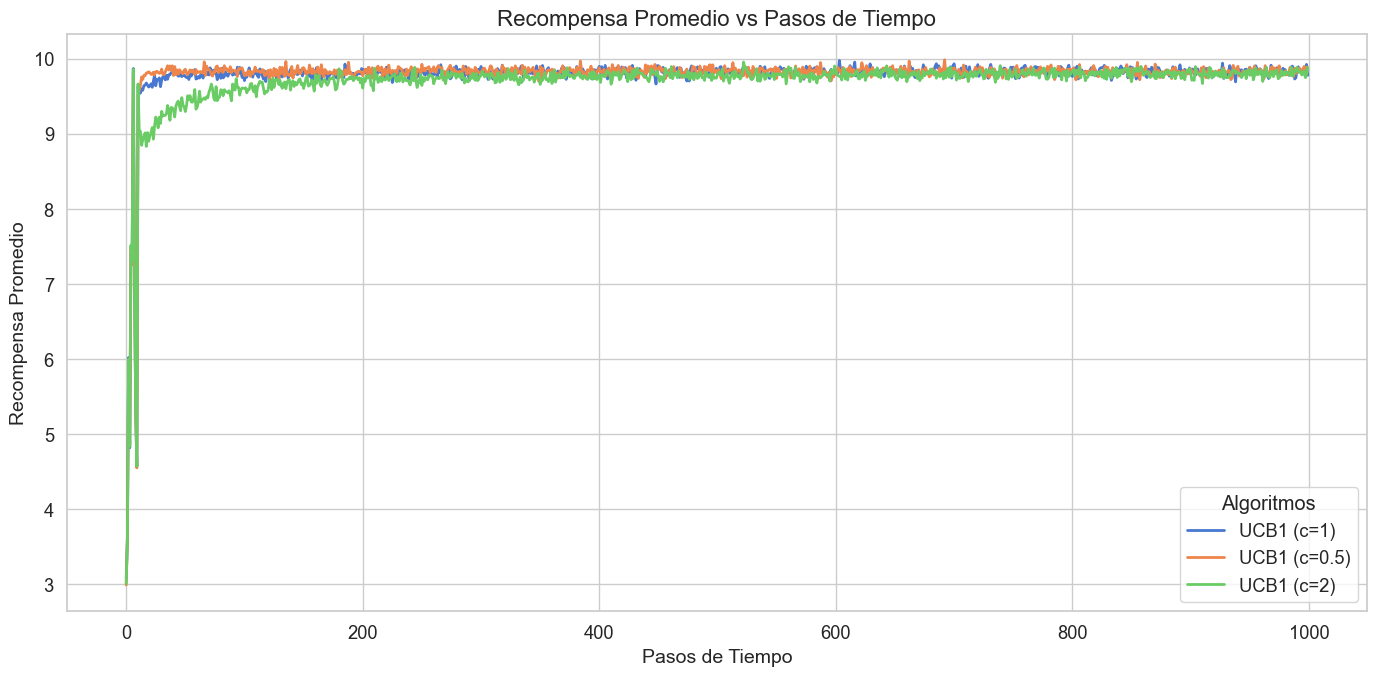

In [6]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)


##### **1.1 Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **UCB1** con distinto valor de **C** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $10$.

* **Línea verde (UCB1 con `C=2`)**: Muestra el rendimiento del algoritmo con `C=2`, que tienda a explorar más que explotar. Esto se puede ver en que al principio le cuesta llegar al brazo con mayor recompensa comparada con los otros algoritmos. Además, al inicio realizar una exploración de todos los brazos, dando lugar a que consiga obtener una recompensa casi máxima.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, que tiende a explotar más que explorar. Esto lo podemos ver en como, después de haber explorado todos los brazos, al encontrar uno con la máxima ganancia, tiende a explotar mucho más que el algoritmo anterior.
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, que tiene un equilibrio entre explotación y exploración. En este caso, obtiene unos resultados similares al naranja, aunque al principio obtiene peores resultados al tender a explorar más que el algormitmo naranja.


Como **conclusiones generales**, vemos que la estrategía de explotar más despues de explorar todos los brazos da lugar a un mejor rendimiento (**UCB1 con `C=0.5`**), mientras que al obligar a explorar cuando ya se tiene un brazo optimo retrasa la llegada a la recompensa máxima alcanzada.


Ahora vamos a analizar el porcentaje de selección del brazo óptimo.



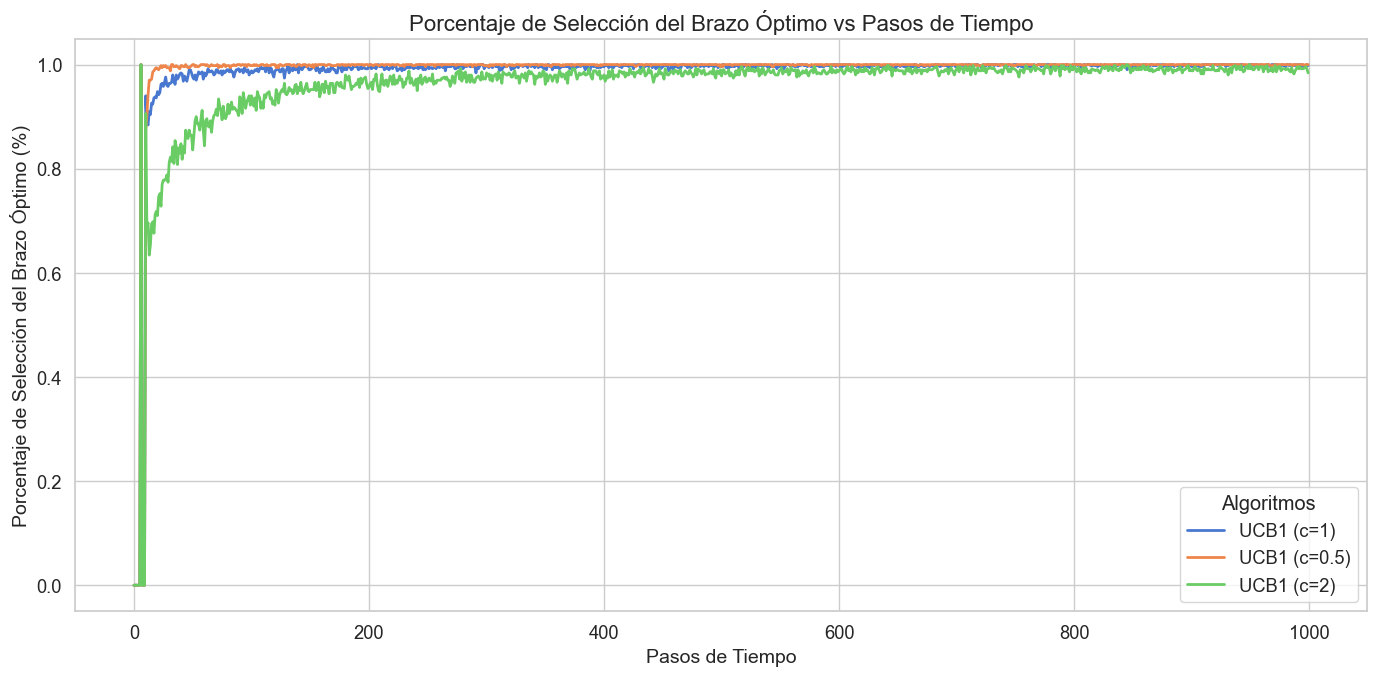

In [7]:
plot_optimal_selections(steps, optimal_selections, algorithms)


##### **1.2 Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo ópitmo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del algoritmo con `C=2`, donde se puede volver a ver el comportamiento de tender más a explorar que a explotar al inicio. De los tres algoritmos, es el que más tarda en llegar al punto de solo seleccionar el mejor brazo.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, donde ahora se vuelve a ver como después de la exploración inicial, es el que más rápido llega al punto óptimo.
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, donde aun siendo un punto intermedio de los dos algoritmos, se acerca más al naranja al tardar un poco más, aunque sigue siendo más rápido que el algoritmo verde.

Como **conclusiones** de esta gráfica, vemos como con la distribución normal y tendiendo a explotar **(UCB1 con `C=0.5`)** después de una exploración inicial, se consigue llegar al punto de solo elegir el brazo óptimo en pocos pasos (~30), mientras que si se tiende a explorar **(UCB1 con `C=2`)**, se tarda drasticamente más en llegar (~400).

Ahora vamos a analizar las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - UCB1 (c=1)
Brazo 1: Recompensa Promedio = 3.0804, Selecciones = 1
Brazo 2: Recompensa Promedio = 3.5969, Selecciones = 1
Brazo 3: Recompensa Promedio = 5.7904, Selecciones = 1
Brazo 4: Recompensa Promedio = 4.7417, Selecciones = 1
Brazo 5: Recompensa Promedio = 7.1745, Selecciones = 2
Brazo 6: Recompensa Promedio = 7.0752, Selecciones = 2
Brazo 7: Recompensa Promedio = 9.8295, Selecciones = 985 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 6.8961, Selecciones = 2
Brazo 9: Recompensa Promedio = 5.2140, Selecciones = 1
Brazo 10: Recompensa Promedio = 4.5147, Selecciones = 1


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


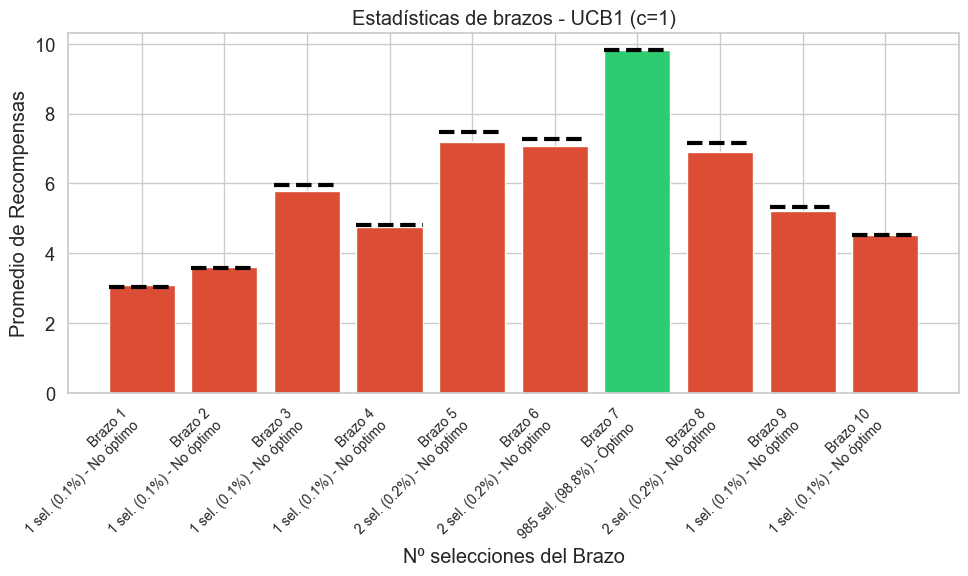

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - UCB1 (c=0.5)
Brazo 1: Recompensa Promedio = 2.9906, Selecciones = 1
Brazo 2: Recompensa Promedio = 3.6365, Selecciones = 1
Brazo 3: Recompensa Promedio = 5.9201, Selecciones = 1
Brazo 4: Recompensa Promedio = 4.8654, Selecciones = 1
Brazo 5: Recompensa Promedio = 7.2515, Selecciones = 1
Brazo 6: Recompensa Promedio = 7.0697, Selecciones = 1
Brazo 7: Recompensa Promedio = 9.8302, Selecciones = 989 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 7.0781, Selecciones = 1
Brazo 9: Recompensa Promedio = 5.3788, Selecciones = 1
Brazo 10: Recompensa Promedio = 4.5499, Selecciones = 1


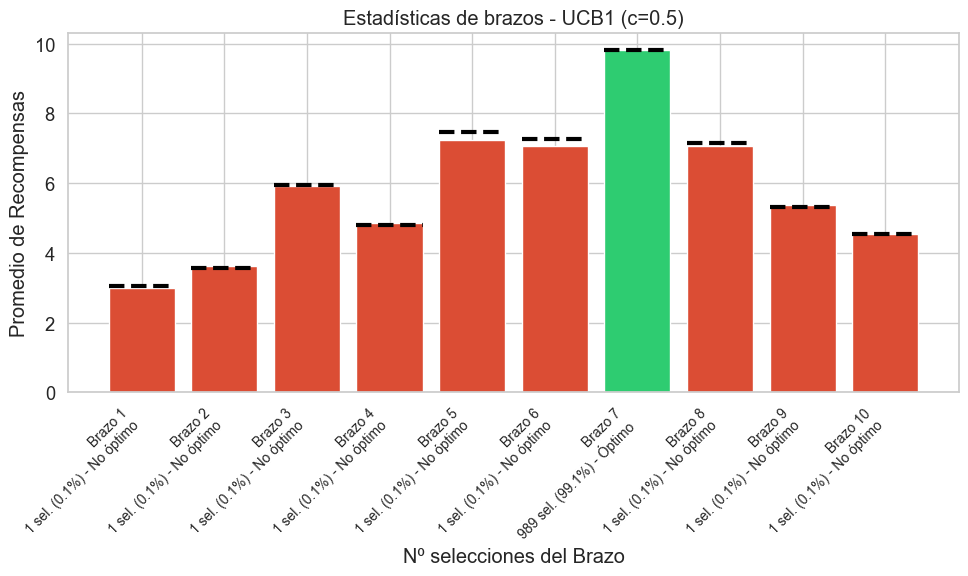


Estadísticas de brazos - UCB1 (c=2)
Brazo 1: Recompensa Promedio = 2.8344, Selecciones = 1
Brazo 2: Recompensa Promedio = 3.4378, Selecciones = 1
Brazo 3: Recompensa Promedio = 5.8684, Selecciones = 3
Brazo 4: Recompensa Promedio = 4.6546, Selecciones = 2
Brazo 5: Recompensa Promedio = 7.4023, Selecciones = 8
Brazo 6: Recompensa Promedio = 7.1776, Selecciones = 7
Brazo 7: Recompensa Promedio = 9.8304, Selecciones = 960 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 7.0738, Selecciones = 7
Brazo 9: Recompensa Promedio = 5.2190, Selecciones = 3
Brazo 10: Recompensa Promedio = 4.4089, Selecciones = 2


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


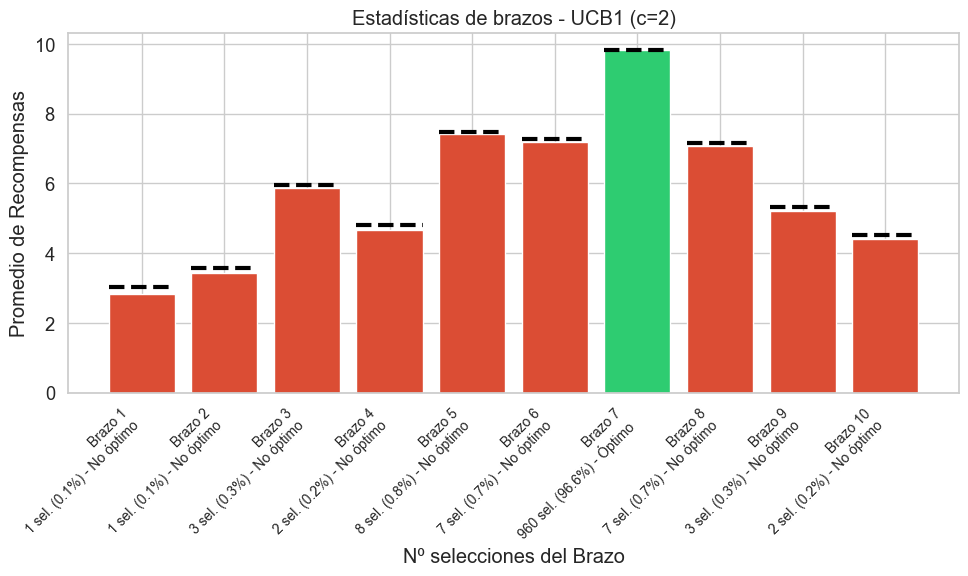

In [8]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])


##### **1.3 Análisis Histogramas selección de brazos**

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

1. **Histograma de UCB1 con `C=1`:** En el primer histograma podemos ver como el brazo que más a elegido ha sido el `7` ($985$ veces), coincidiendo con el brazo óptimo del bandido. Además, podemos ver como cada brazo se ha elegido al menos una vez por la exploración inicial y como los siguientes brazos con mayor ganancia (`5`, `6` y `8`) se han seleccionado una vez más, esto es debido a que este algoritmo no tiene una tendencia clara a explotar o explorar, por lo que al inicio se dió el caso de explorar a los otros mejores brazos del bandido.
2. **Histograma de UCB1 con `C=0.5`:** En el segundo histograma, el brazo que más veces se eligió fue el `7` ($989$ veces), volviendo a coincidir con el brazo óptimo del bandido. También vemos esa primera explorar al seleccionar todos los brazos al menos una vez, aunque en este caso, no vuelve a seleccionarlos al tender a explotar y haber un diferencia clara entre el mejor brazo y los siguientes mejores.
3. **Histograma de UCB1 con `C=2`:** En el tercer histograma, el brazo que más veces se eligió fue el `7` ($960$ veces), volviendo a coincidir con el brazo óptimo del bandido. Esta vez vemos como el resto de brazos son seleccionados más veces que los algoritmos anteriores, aunque lo hagan en proporción a su recompensa promedio. Esta selección del resto de brazos se debe a buscar explorar más los brazos, sobre todo al inicio que ocurren estas selecciones al resto de brazos.

Como **conclusiones** de estos histogramas:

* El algoritmo **UCB1 con `C=0.5`** es el que más veces elige el brazo óptimo al explotar una vez encontrado.
* Todos los algoritmos seleccionan cada brazo al menos una vez, ayudando a saber cuales explotar.
* El algoritmo **UCB1 con `C=2`** es el que menos veces elige el brazo óptimo al explorar el resto de brazos más veces al inicio.

Ahora, vamos a analizar los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.



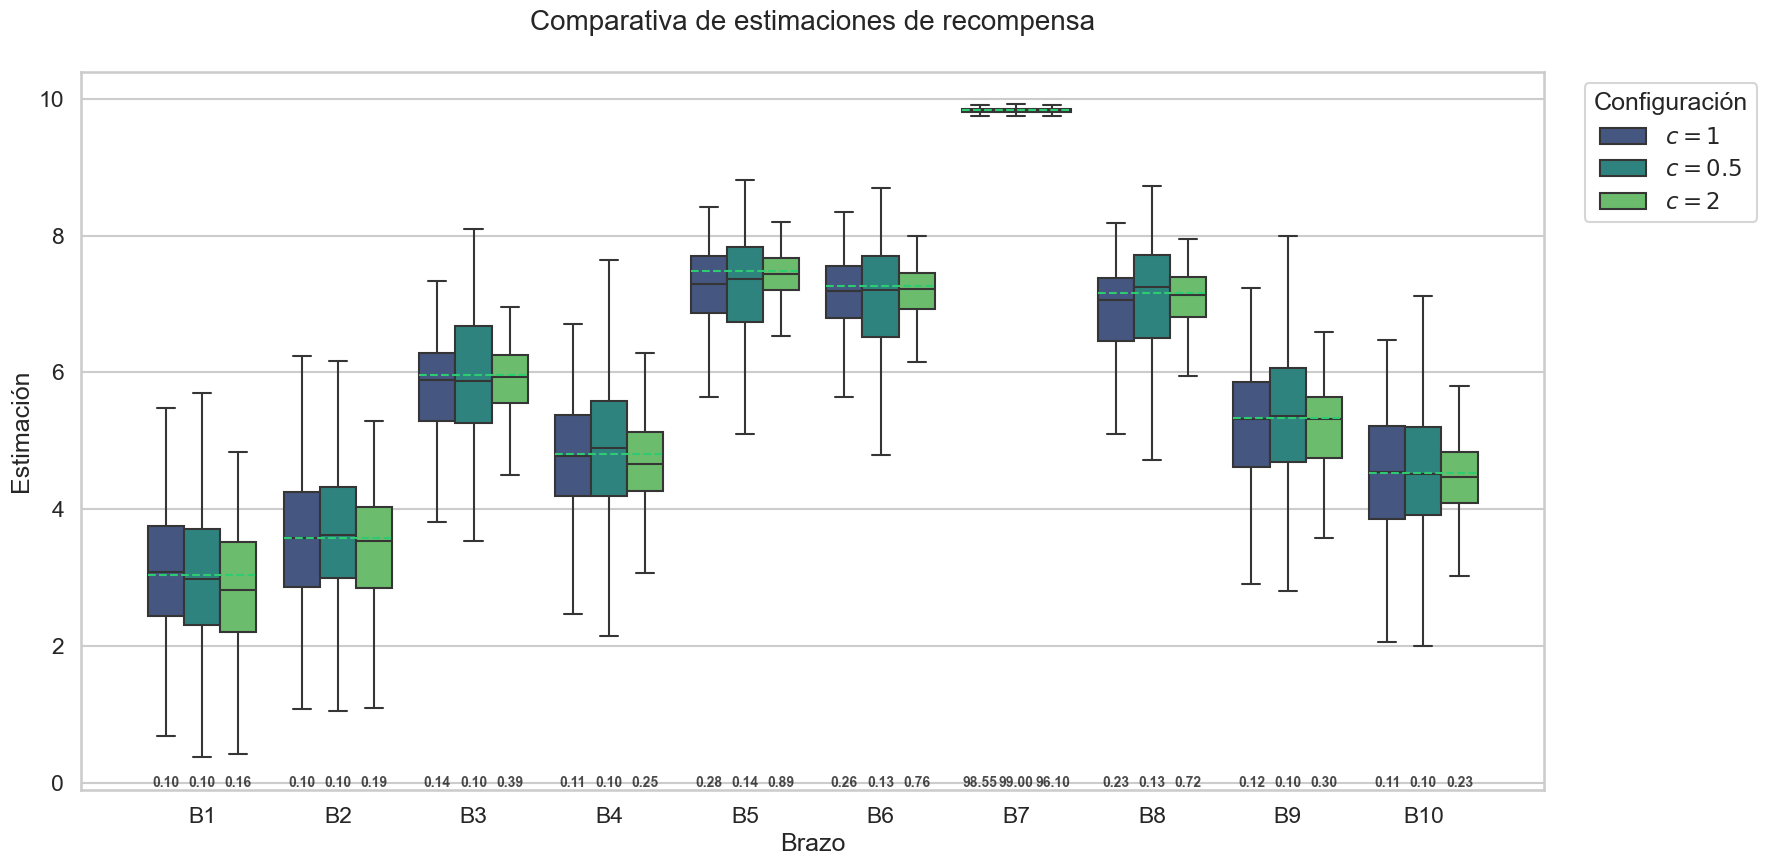

In [9]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **1.4 Análisis Boxplots de estimaciones de recompensas de cada brazo**

Esta gráfica muestra los boxplots de las estimaciones de recompensas promedio según el número de veces que han sido seleccionado cada brazo. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **UCB1 con `C=1`**, el segundo el **UCB1 con `C=0.5`** y el tercero **UCB1 con `C=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (UCB1 con `C=1`)**: Para el primer algoritmo, se puede apreciar como en todos los brazos, a excepción del 7, los boxplots se dilatan bastante, aunque el valaor medio de la recompensa se situa cerca del valor real. Esto se debe a que, como se ve debajo, estos brazos no son escogidos muchas veces como vimos anteriormente, dando lugar a no poder visualizar el valor real. Sin embargo, con el brazo 7, siendo este el óptimo y el que más selecciona, sí encontramos un boxplot más encajado en el valor real.
* **Algoritmo 2 (UCB1 con `C=0.5`)**: Para el segundo algoritmo, nos encontramos con una situación similar a la anterior, aunque ahora hay algunos brazo, como el tercero y el cuarto, que las estimasciones se dilatan más. Esto se debe a que al ser el algoritmo que explota en mayor medida, no logra seleccionar esos otros brazos en más ocasiones, ocasionando que la estimación no se ajuste al valor real. Por otro lado, también vemos como se ajusta perfectamente en el brazo 7 al valor real.
* **Algoritmo 3 (UCB1 con `C=2`)**: Para el tercer algoritmo, ahora en todos los brazos se consigue un mejor ajuste a los valores reales, debido a que consigue explorar más esos brazos comparado con los otros algoritmos.

Como **conclusiones** de esta gráfica podemos sacar que cuando el algoritmo selecciona más veces un brazo, este cosigue poco a poco ajustarse al valor real, mientras que si solo lo selecciona una o dos veces, logra una estimación menos precisa.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

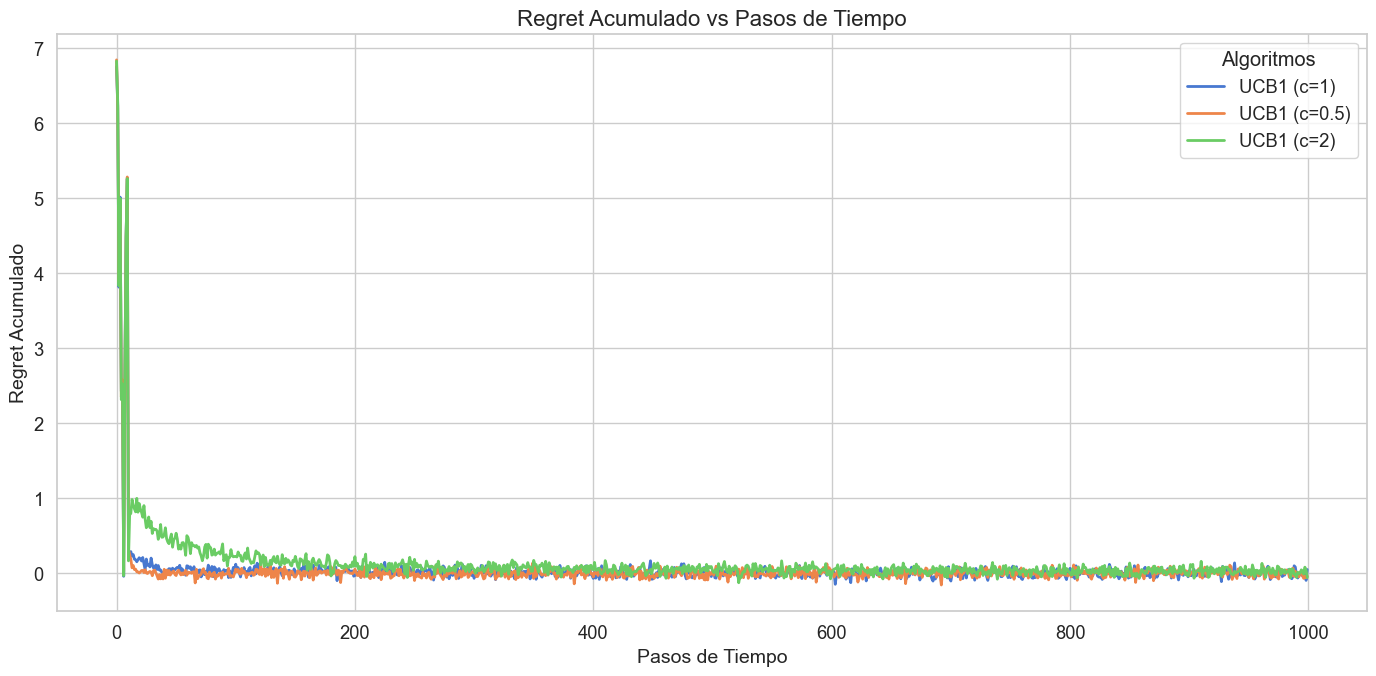

In [10]:
plot_regret(steps, regrets, algorithms)

##### **1.5 Análisis arrepentimiento acomulado**

Esta gráfica muestra la **evolución del arrepentimiento acomulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acomulado, desde $0$ hasta $7$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acomulado

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explorar,dando lugar a que al inicio tarde más en llegar al valor de arrepentimiento óptimo que alcanzan el resto de algoritmos.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestras la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explotar, dando lugar a ser el que más rápido llega al valor óptimo.
* **Línea azul (UCB1 con `C=1`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que no tiene una tendencia clara de explorar o explotar, obteniendo unos resultados similares al naranaj, aunque tarde ligeramente más en llegar al punto óptimo.

Como **conclusiones** de esta gráfica, vemos como tanto el algoritmo de **UCB1 con `C=0.5`** y **UCB1 con `C=1`** tardan poco en llegar al punto óptimo, mientras que el **UCB1 con `C=2`** tarda drasticamente más. Además, debido a la exploración inicial de todos los algoritmos al inicio, se ve un pico de arrepentimiento que luego se reduce hasta llegar al punto óptimo. Una vez que se han estabilizado los tres algoritmos, no se ve una clara diferencia de cual obtiene un menor valor.

### **``2. Experimento distribución Bernoulli``**
En segundo lugar, vamos a realizar el experimento del algoritmo de UCB con valores de C de $0.5$, $1$ y $2$, con 10 brazos de distribución Bernoulli, durante 1000 pasos y repitiendose 500 veces cada algoritmo. 

In [11]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución de Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos UCB1con diferentes valores de c.
algorithms = [UCB1(k=k, c=1),UCB1(k=k, c=0.5),UCB1(k=k, c=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBernoulli(p=0.84), ArmBernoulli(p=0.87), ArmBernoulli(p=0.43), ArmBernoulli(p=0.29), ArmBernoulli(p=0.0), ArmBernoulli(p=0.86), ArmBernoulli(p=0.33), ArmBernoulli(p=0.76), ArmBernoulli(p=0.27), ArmBernoulli(p=0.06)
Optimal arm: 2 with expected reward=0.87


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución bernoulli. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento.
* Evolución del porcentaje de la selección del mejor brazo.
* Número de veces que se ha seleccionado cada brazo en el experimento.
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento.

Para empezar, vamos a analizar de la evolución de la recompensa promedio

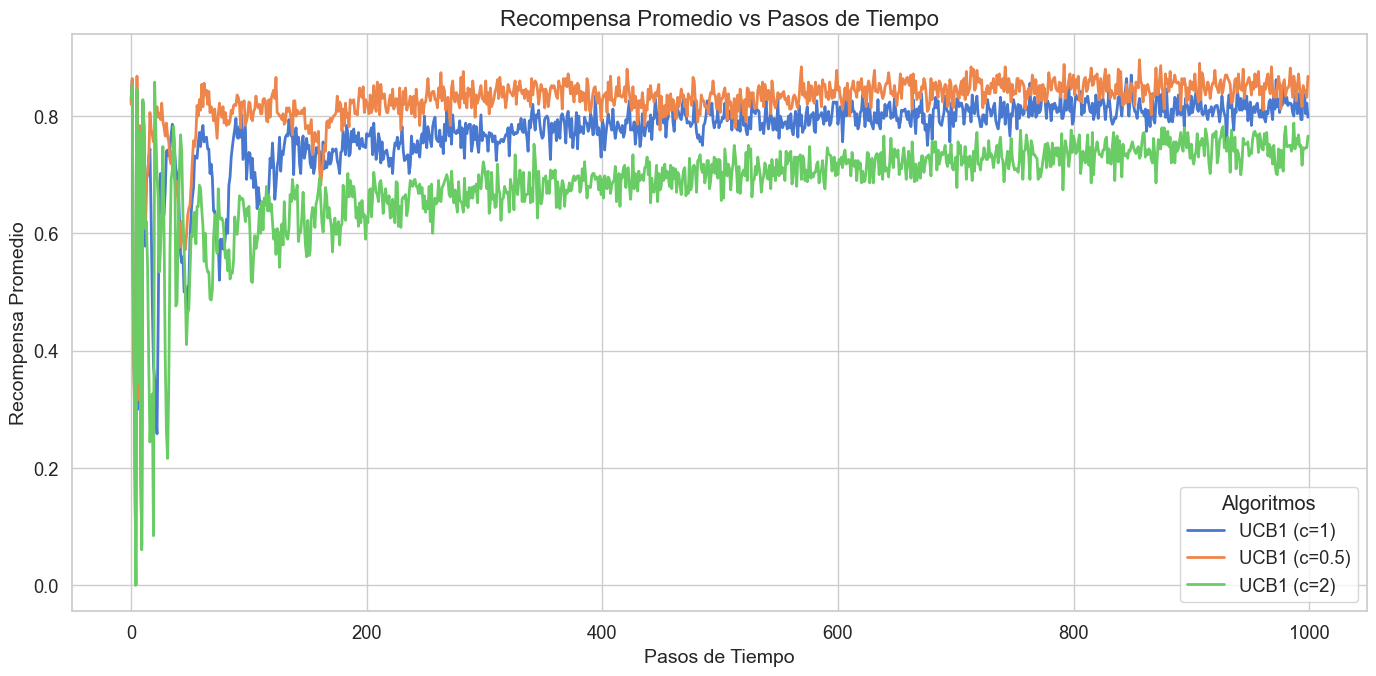

In [12]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)


##### **Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **UCB1** con distinto valor de **C** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $1$.

* **Línea verde (UCB1 con `C=2`)**: Muestra el rendimiento del algoritmo con `C=2`, que tienda a explorar más que explotar, dando lugar a un lento aprendizaje comparado al resto. Además, cuando consigue estabilizarse al final, se queda por debajo del resto de algoritmos.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, que tiende a explotar más que explorar. Esto lo podemos ver en como es el algoritmo que más rápido consigue estabilizarse, además de ser el que más se acerca al valor de recompensa real ($0.87$).
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, que tiene un equilibrio entre explotación y exploración. En este caso, obtiene unos resultados similares ligeramente peores al naranja, pero mejores que al verde debido a que no tiende a explorar tanto comparado con el algoritmo verde.


Como **conclusiones generales**, vemos que la estrategía de explotar más despues de explorar todos los brazos da lugar a un mejor rendimiento (**UCB1 con `C=0.5`**), mientras que al obligar a explorar cuando ya se tiene un brazo optimo retrasa la llegada a la recompensa máxima alcanzada, de la misma forma que nos pasaba con la distribución normal. Por otro lado, al incio del experimento, vemos como los tres algoritmos tienden a realizar muchas más exploraciones comparadas con la distribución anterior debido a que ahora el valor real de recompensa es más bajo y próximo al valor de recompensas de otros brazos.


Ahora vamos a analizar el porcentaje de selección del brazo óptimo.

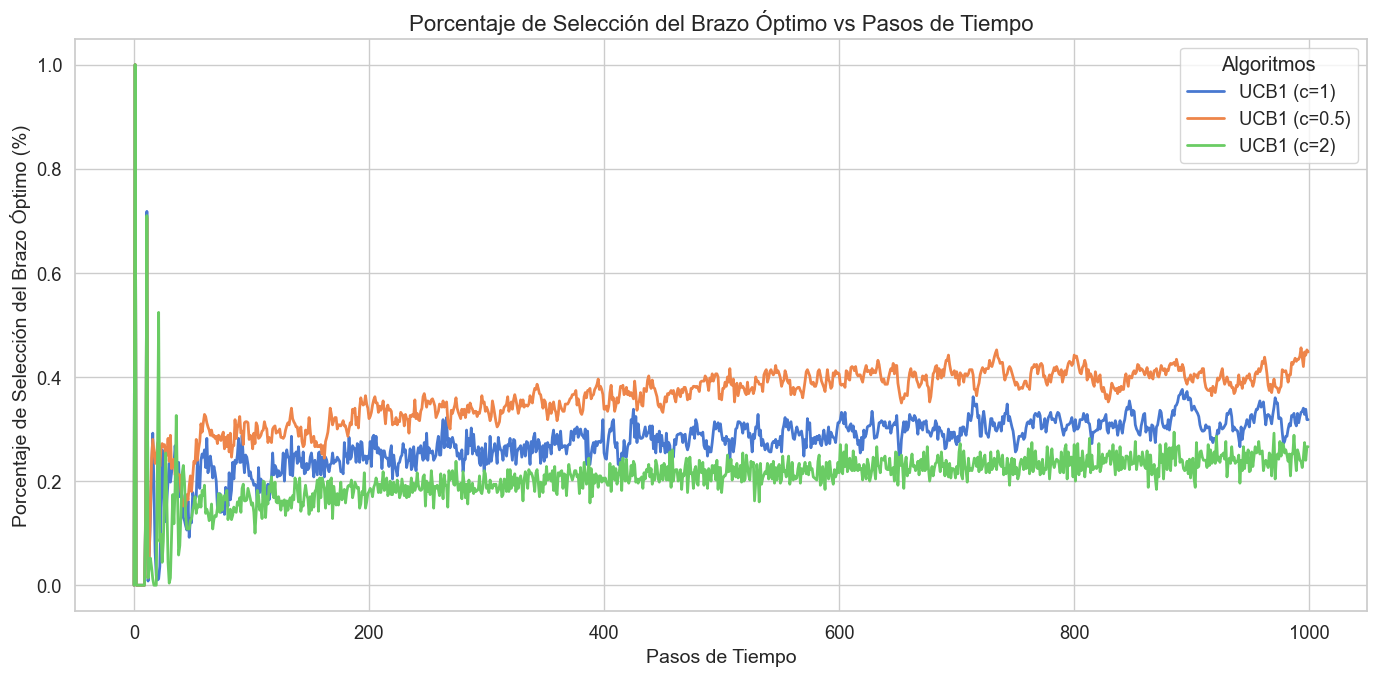

In [13]:
plot_optimal_selections(steps, optimal_selections, algorithms)


##### **Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo ópitmo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del algoritmo con `C=2`, donde se puede ver que, despues de una primera exploración en todos los brazos, el algoritmo no logra consiguir un porcentaje alto de selección del óptimo. Esto se puede deber a la existencia de otros brazos con valores de recompensas similares que, al añadirse la tendecia a explorar, no logra explotar correctamente el brazo óptimo.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, donde ocurre algo similar al algorimo anterior, aunque ahora logra explotar en una mayor medida el brazo óptimo, consiguiendo un $0.44%$ aproximadamente.
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, donde volvemos a encontrar una situación similar a las anteriores, aunque se queda en un punto medio de los dos algoritmos.

Como **conclusiones** de esta gráfica, vemos como con la distribución Bernoulli, los algoritmos presentan un peor rendimiento en la explotación del brazo óptimo comparado con la distribución normal. Además, se repite el hecho de que el algoritmo **UCB1 con `C=0.5`** es el que mejor resultados da.

Ahora vamos a analizar las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - UCB1 (c=1)
Brazo 1: Recompensa Promedio = 0.8354, Selecciones = 215
Brazo 2: Recompensa Promedio = 0.8651, Selecciones = 274 (ÓPTIMO)
Brazo 3: Recompensa Promedio = 0.4115, Selecciones = 32
Brazo 4: Recompensa Promedio = 0.2660, Selecciones = 21
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 12
Brazo 6: Recompensa Promedio = 0.8586, Selecciones = 259
Brazo 7: Recompensa Promedio = 0.3072, Selecciones = 24
Brazo 8: Recompensa Promedio = 0.7526, Selecciones = 125
Brazo 9: Recompensa Promedio = 0.2456, Selecciones = 20
Brazo 10: Recompensa Promedio = 0.0542, Selecciones = 13


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


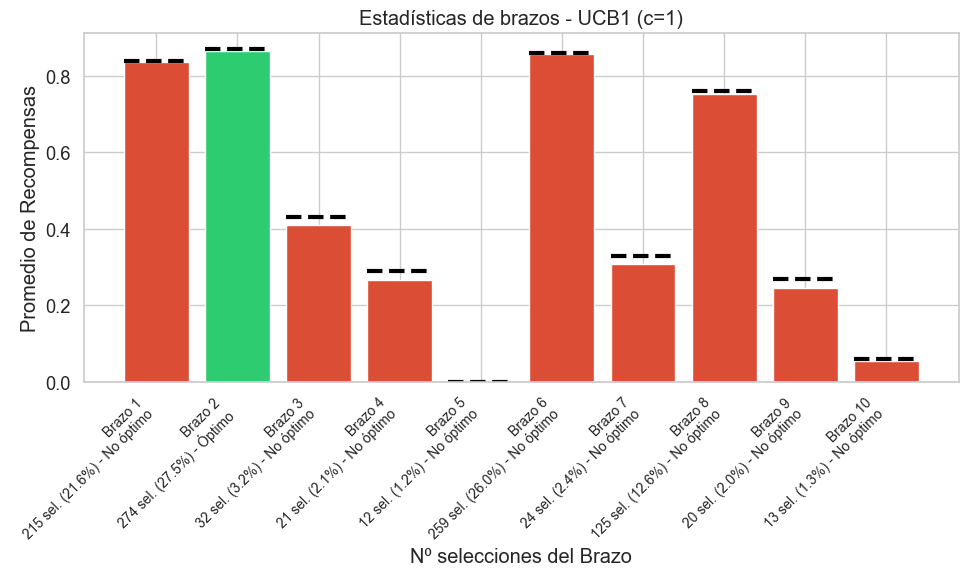

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - UCB1 (c=0.5)
Brazo 1: Recompensa Promedio = 0.8267, Selecciones = 208
Brazo 2: Recompensa Promedio = 0.8649, Selecciones = 359 (ÓPTIMO)
Brazo 3: Recompensa Promedio = 0.3592, Selecciones = 12
Brazo 4: Recompensa Promedio = 0.2175, Selecciones = 7
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 4
Brazo 6: Recompensa Promedio = 0.8553, Selecciones = 308
Brazo 7: Recompensa Promedio = 0.2539, Selecciones = 8
Brazo 8: Recompensa Promedio = 0.7268, Selecciones = 77
Brazo 9: Recompensa Promedio = 0.2029, Selecciones = 7
Brazo 10: Recompensa Promedio = 0.0459, Selecciones = 4


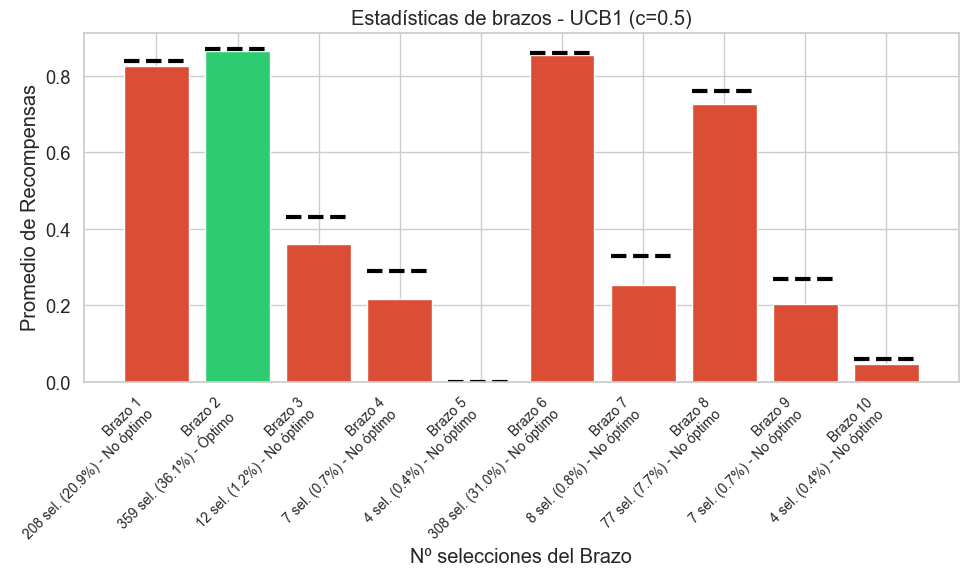


Estadísticas de brazos - UCB1 (c=2)
Brazo 1: Recompensa Promedio = 0.8388, Selecciones = 186
Brazo 2: Recompensa Promedio = 0.8684, Selecciones = 207 (ÓPTIMO)
Brazo 3: Recompensa Promedio = 0.4228, Selecciones = 61
Brazo 4: Recompensa Promedio = 0.2833, Selecciones = 46
Brazo 5: Recompensa Promedio = 0.0000, Selecciones = 29
Brazo 6: Recompensa Promedio = 0.8589, Selecciones = 200
Brazo 7: Recompensa Promedio = 0.3199, Selecciones = 49
Brazo 8: Recompensa Promedio = 0.7587, Selecciones = 142
Brazo 9: Recompensa Promedio = 0.2613, Selecciones = 44
Brazo 10: Recompensa Promedio = 0.0589, Selecciones = 31


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


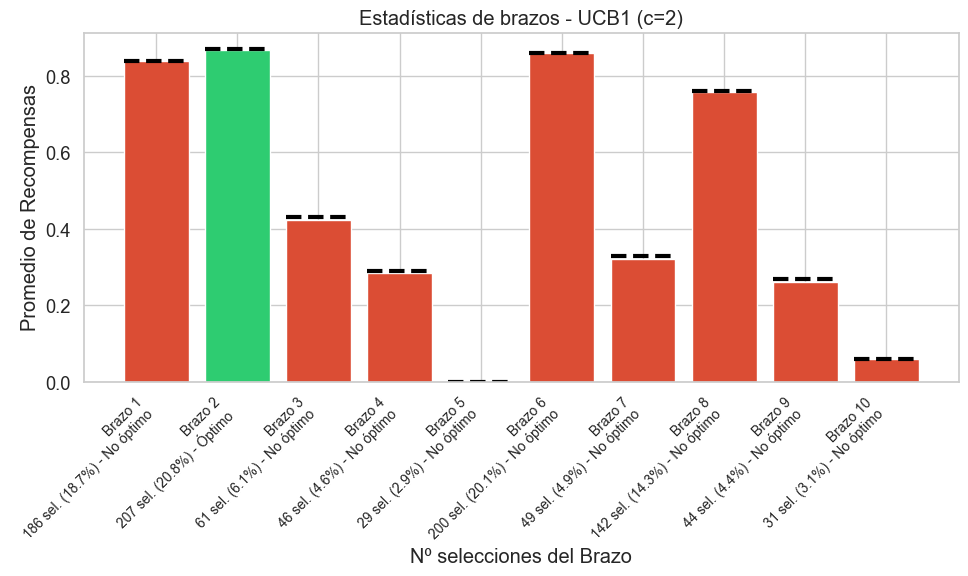

In [14]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])


##### **Análisis Histogramas selección de brazos**

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

1. **Histograma de UCB1 con `C=1`:** En el primer histograma podemos ver como el brazo que más a elegido ha sido el `2` ($274$ veces), coincidiendo con el brazo óptimo del bandido. Sin embargo, también selecciona en similar medida los brazos ``1`` y ``6``, debido a que estos también cuentan con una valor de recompensa muy similar, ocasionando que no logre explotar en igual medida que antes ese brazo óptimo, aunque la perdida no sea tan grande al ser recompensas similares.

2. **Histograma de UCB1 con `C=0.5`:** En el segundo histograma, el brazo que más veces se eligió fue el `2` ($359$ veces), volviendo a coincidir con el brazo óptimo del bandido. También observamos que los brazos ``1`` y ``6`` cuentan con un alto número de selecciones, consiguiendo que este algoritmo explote en mayor medida aquellos brazos con un alto valor de recompensa.
3. **Histograma de UCB1 con `C=2`:** En el tercer histograma, el brazo que más veces se eligió fue el `2` ($207$ veces), volviendo a coincidir con el brazo óptimo del bandido. Esta vez, los brazos ``1``, ``6`` y ``8`` se encuentran más cerca que el brazo óptimo, al tender este algoritmo a la exploraciones de los brazos con recompensas similares.

Como **conclusiones** de estos histogramas:

* El algoritmo **UCB1 con `C=0.5`** es el que más veces elige el brazo óptimo al explotar una vez encontrado.
* A diferencia de la distribución normal, ahora los brazos seleccionan otros brazos menos óptimos, aunque se debe a que sus recompensas son muy similares a la óptima. Además, cuando el algoritmo tiene más a explotar, selecciona más aquellos brazos con recompensas cercanas a la óptima-
* El algoritmo **UCB1 con `C=2`** es el que menos veces elige el brazo óptimo al explorar el resto de brazos más veces al inicio y durante el experiento.

Ahora, vamos a analizar los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.

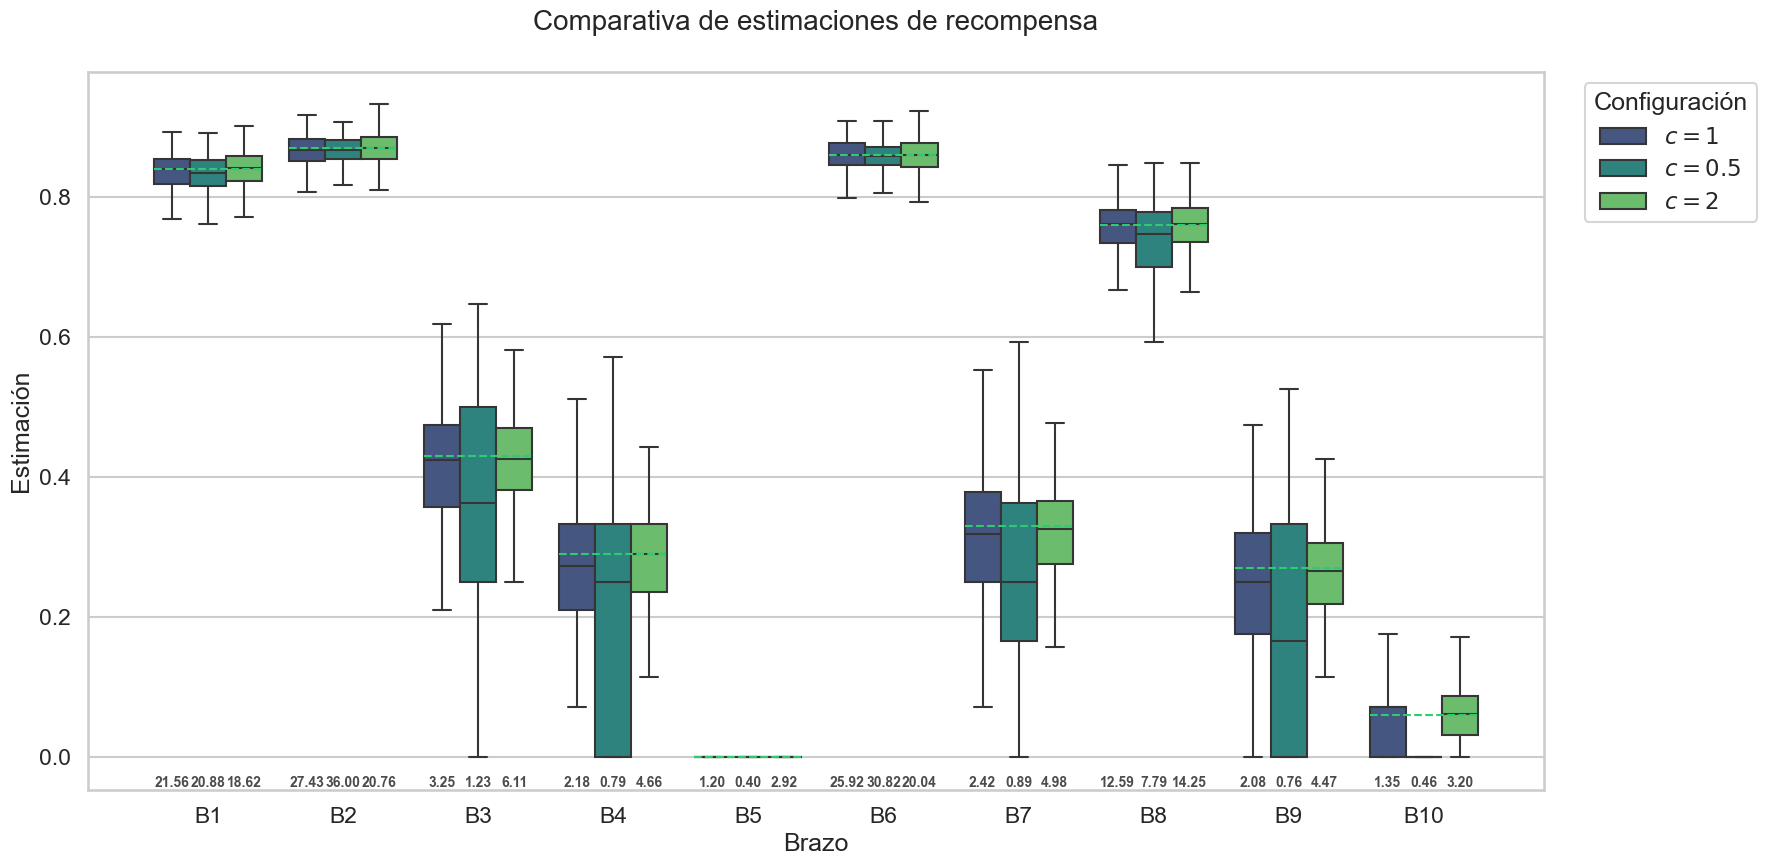

In [15]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **Análisis Boxplots de estimaciones de recompensas de cada brazo**

Esta gráfica muestra los boxplots de las estimaciones de recompensas promedio según el número de veces que han sido seleccionado cada brazo. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **UCB1 con `C=1`**, el segundo el **UCB1 con `C=0.5`** y el tercero **UCB1 con `C=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (UCB1 con `C=1`)**: Para el primer algoritmo, se puede apreciar como en aquellos brazos que cuentan con una recompensa alta similar (``1``, ``2`` y ``6``), al ser seleccionados varias veces, consiguen ajustar bastante las estimaciones al valor real, aunque no logra el mismo nivel de precisión que con la distribución normal. Por otro lado, los brazos ``5`` y ``10`` que cuentan con un valor real muy bajo, consiguen estimar con bastante precisión su baja estimación.
* **Algoritmo 2 (UCB1 con `C=0.5`)**: Para el segundo algoritmo, se repite las boxplots para los brazos que mejores recompensas tienen y los que menos (``5`` y ``10``). Sin embargo, para el resto de brazos, al ser seleccionados en menor medida, consiguen estimaciones más dilatadas.
* **Algoritmo 3 (UCB1 con `C=2`)**: Para el tercer algoritmo, ahora en todos los brazos que tenian estiamciones en un punto media, al ser ahora más veces seleccionados debido a la tendencia de querer explorar más, se consigue un mejor ajuste.

Como **conclusiones** de esta gráfica podemos sacar que se sigue cumpliendo que cuando más veces se selecciona un brazo, este consigue un mejor ajuste al valor real de recompensa.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

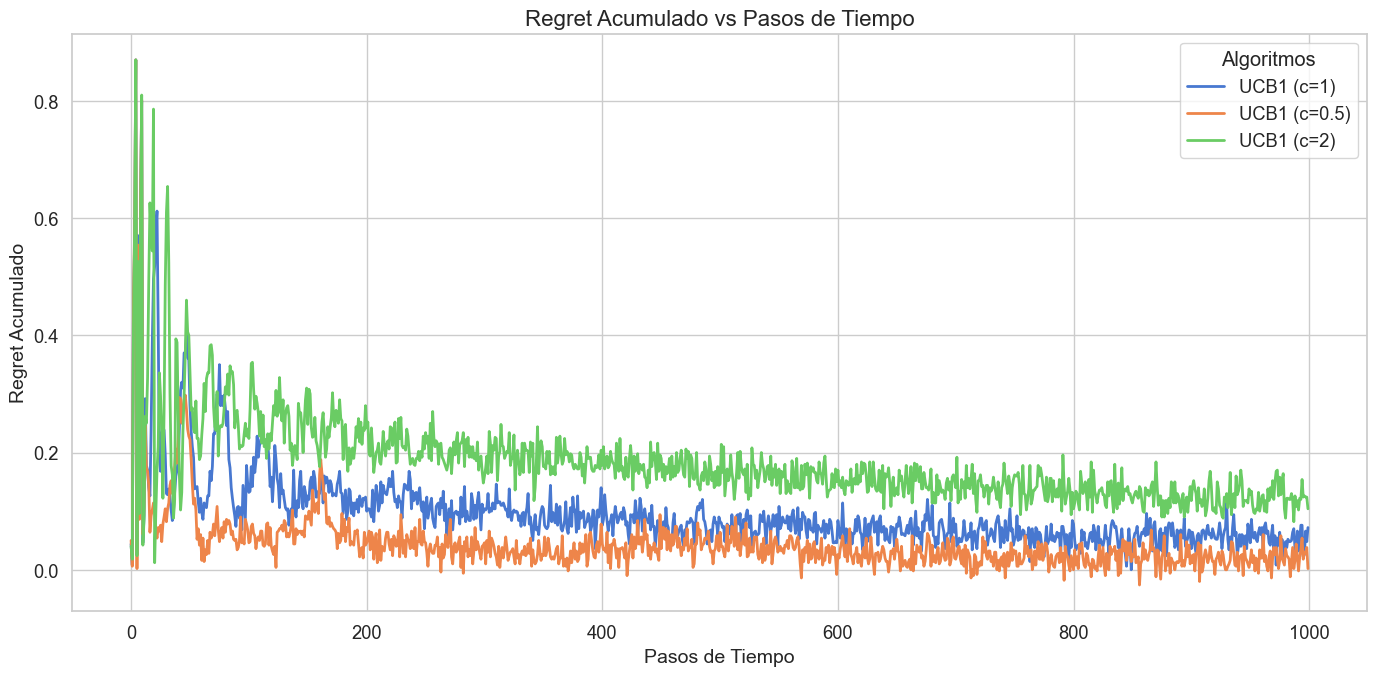

In [16]:
plot_regret(steps, regrets, algorithms)

##### **Análisis arrepentimiento acomulado**

Esta gráfica muestra la **evolución del arrepentimiento acomulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acomulado, desde $0$ hasta $1$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acomulado

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explorar, dando lugar a que durante el experimento sea la que mayor arrepentimiento acomulado tiene.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestras la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explotar, dando lugar a ser el que más rápido llega al menor valor de los tres algoritmos.
* **Línea azul (UCB1 con `C=1`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que no tiene una tendencia clara de explorar o explotar, obteniendo unos resultados similares al naranja, aunque se quede ligeramente por encima de él.

Como **conclusiones** de esta gráfica, vemos como tanto el algoritmo de **UCB1 con `C=0.5`** es el que más rápido llega a un valor de arrepentimiento menor que el resto de algoritmos debido a su tendencia a explotar aquellos brazos que mejores recompensas tienen.

### **``3. Experimento distribución Binomial``**
En tercer lugar, vamos a realizar el experimento del algoritmo de UCB con valores de C de $0.5$, $1$ y $2$, con 10 brazos de distribución binomial, durante 1000 pasos y repitiendose 500 veces cada algoritmo.

In [17]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [UCB1(k=k, c=1),UCB1(k=k, c=0.5),UCB1(k=k, c=2)]

# Ejecutar el experimento y obtener las recompensas promedio, porcentaje de selecciones óptimas y estadísticas de brazos
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit with 10 arms: ArmBinomial(n=10, p=0.5), ArmBinomial(n=10, p=0.55), ArmBinomial(n=10, p=0.1), ArmBinomial(n=10, p=0.74), ArmBinomial(n=10, p=0.36), ArmBinomial(n=10, p=0.46), ArmBinomial(n=10, p=0.9), ArmBinomial(n=10, p=0.05), ArmBinomial(n=10, p=0.35), ArmBinomial(n=10, p=0.48)
Optimal arm: 7 with expected reward=9.0


#### **Visualización**

En esta apartado vamos a mostrar y analizar las diferentes gráficas generadas para el experimento del bandido de k-brazos con distribución binomial. Las gráficas que se van mostrar son las siguientes:

* Evolución de la recompensa promedio durante el experimento.
* Evolución del porcentaje de la selección del mejor brazo.
* Número de veces que se ha seleccionado cada brazo en el experimento.
* Boxplots de las estimaciones de recompensa por cada brazo.
* Evolución del arrepentimiento durante el experimento.

Para empezar, vamos a analizar de la evolución de la recompensa promedio

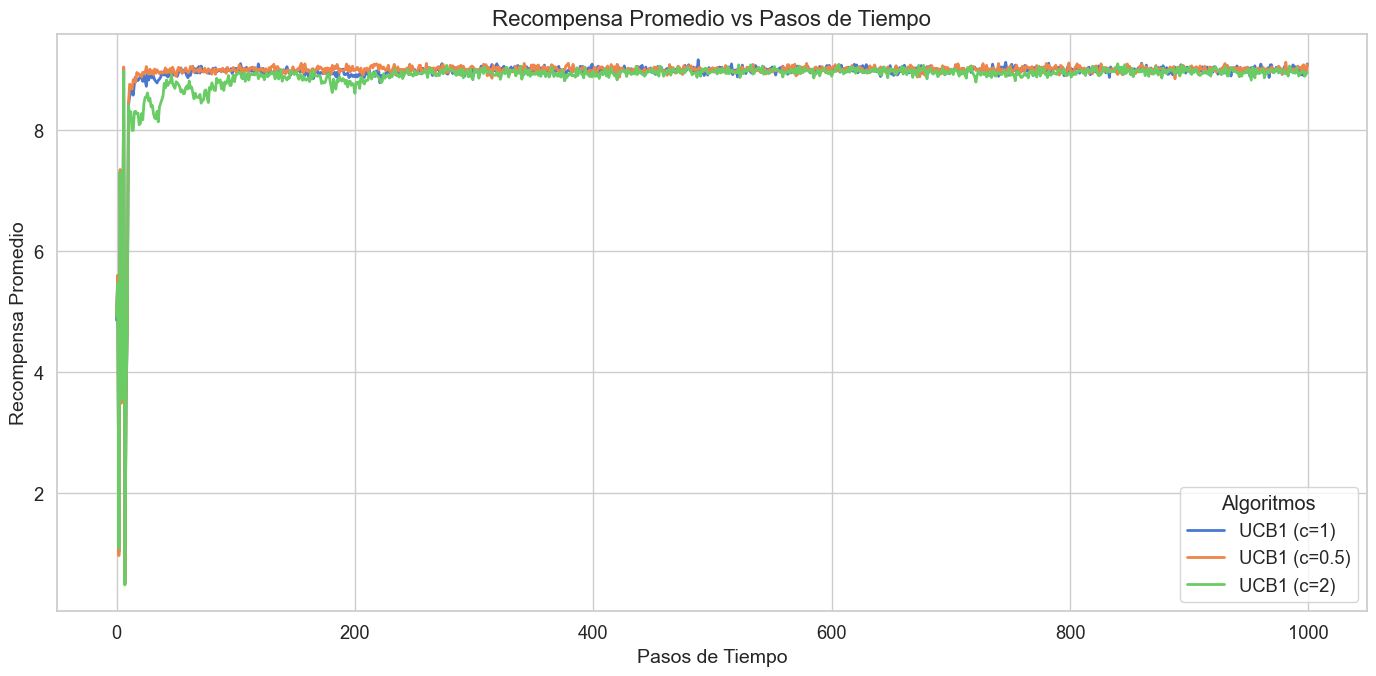

In [18]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)


##### **Análisis Recompensa promedio**

La gráfica muestra la recompensa promedia de los tres algoritmos de **UCB1** con distinto valor de **C** durante los pasos de la ejecución. En el eje **x** se muestra los pasos de tiempo que van desde $0$ hasta $1000$ y en el eje **y** se muestra las recompensas promedio obtenidas en cada paso que van desde $0$ hasta $10$.

* **Línea verde (UCB1 con `C=2`)**: Muestra el rendimiento del algoritmo con `C=2`, que tienda a explorar más que explotar. Esto se puede ver en que al principio le cuesta llegar al brazo con mayor recompensa comparada con los otros algoritmos. Una vez se estabiliza, logra llegar al punto óptimo similar al resto de algoritmos.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, que tiende a explotar más que explorar. Esto lo podemos ver en como, después de haber explorado todos los brazos, al encontrar uno con la máxima ganancia, tiende a explotar mucho más que el algoritmo anterior.
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, que tiene un equilibrio entre explotación y exploración. En este caso, obtiene unos resultados similares al naranja, aunque al principio obtiene peores resultados al tender a explorar más que el algormitmo naranja.

Como **conclusiones generales**, vemos que la estrategía de explotar más despues de explorar todos los brazos da lugar a un mejor rendimiento (**UCB1 con `C=0.5`**), mientras que al obligar a explorar cuando ya se tiene un brazo optimo retrasa la llegada a la recompensa máxima alcanzada. Estos resultados se parecen bastante a los obtenidos en los brazos de distribución normal.


Ahora vamos a analizar el porcentaje de selección del brazo óptimo.

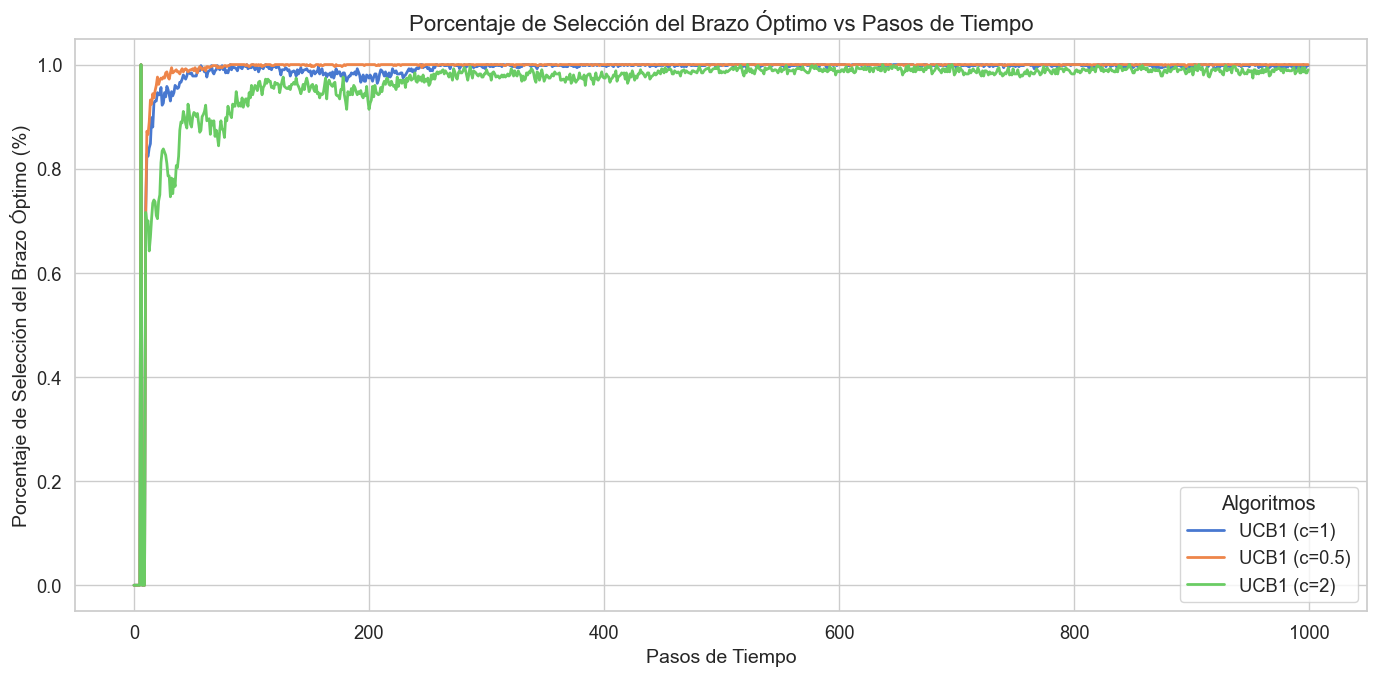

In [19]:
plot_optimal_selections(steps, optimal_selections, algorithms)


##### **Análisis Porcentaje selección óptimo**

Esta gráfica muestra la **evolución del porcentaje de selección del brazo ópitmo** durante la ejecución. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el porcentaje de selección del brazo óptimo, de $0$ a $1$.

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del algoritmo con `C=2`, donde se puede volver a ver el comportamiento de tender más a explorar que a explotar al inicio. De los tres algoritmos, es el que más tarda en llegar al punto de solo seleccionar el mejor brazo, ocurriendo en ocasiones que selecciona otros brazos en algunos puntos.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra el rendimiento del algoritmo con `C=0.5`, donde ahora se vuelve a ver como después de la exploración inicial, es el que más rápido llega al punto óptimo y mantiene esa explotación del brazo óptimo.
* **Línea azul (UCB1 con `C=1`)**: Muestra el rendimiento del algoritmo con `C=1`, donde aun siendo un punto intermedio de los dos algoritmos, se acerca más al naranja al tardar un poco más, aunque sigue siendo más rápido y estable que el algoritmo verde.

Como **conclusiones** de esta gráfica, vemos como con la distribución binomial y tendiendo a explotar **(UCB1 con `C=0.5`)** después de una exploración inicial, se consigue llegar al punto de solo elegir el brazo óptimo en pocos pasos (~90), mientras que si se tiende a explorar **(UCB1 con `C=2`)**, se tarda drasticamente más en llegar (~450). Comparado con los brazos de distribución normal, en esta ocasión tardan ligeramente más en llegar al 100%, aunque se puede deber a que ahora el valor de recompensa del brazo óptimo es ligeramente menor que con la distribución normal.

Ahora vamos a analizar las estadísticas de la selección de cada brazo para cada algoritmo.


Estadísticas de brazos - UCB1 (c=1)
Brazo 1: Recompensa Promedio = 4.5243, Selecciones = 1
Brazo 2: Recompensa Promedio = 5.1234, Selecciones = 1
Brazo 3: Recompensa Promedio = 1.0290, Selecciones = 1
Brazo 4: Recompensa Promedio = 6.8961, Selecciones = 5
Brazo 5: Recompensa Promedio = 3.4940, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.3903, Selecciones = 1
Brazo 7: Recompensa Promedio = 8.9983, Selecciones = 984 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 0.5060, Selecciones = 1
Brazo 9: Recompensa Promedio = 3.3210, Selecciones = 1
Brazo 10: Recompensa Promedio = 4.3573, Selecciones = 1


c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)


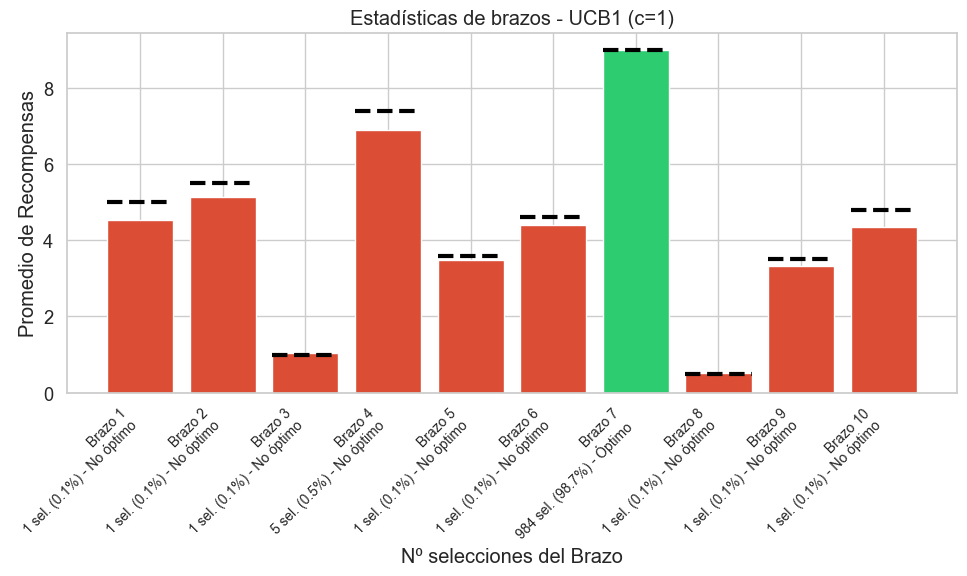

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - UCB1 (c=0.5)
Brazo 1: Recompensa Promedio = 4.8837, Selecciones = 1
Brazo 2: Recompensa Promedio = 5.4350, Selecciones = 1
Brazo 3: Recompensa Promedio = 0.9720, Selecciones = 1
Brazo 4: Recompensa Promedio = 6.8495, Selecciones = 2
Brazo 5: Recompensa Promedio = 3.4760, Selecciones = 1
Brazo 6: Recompensa Promedio = 4.5187, Selecciones = 1
Brazo 7: Recompensa Promedio = 9.0030, Selecciones = 989 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 0.5000, Selecciones = 1
Brazo 9: Recompensa Promedio = 3.4770, Selecciones = 1
Brazo 10: Recompensa Promedio = 4.7730, Selecciones = 1


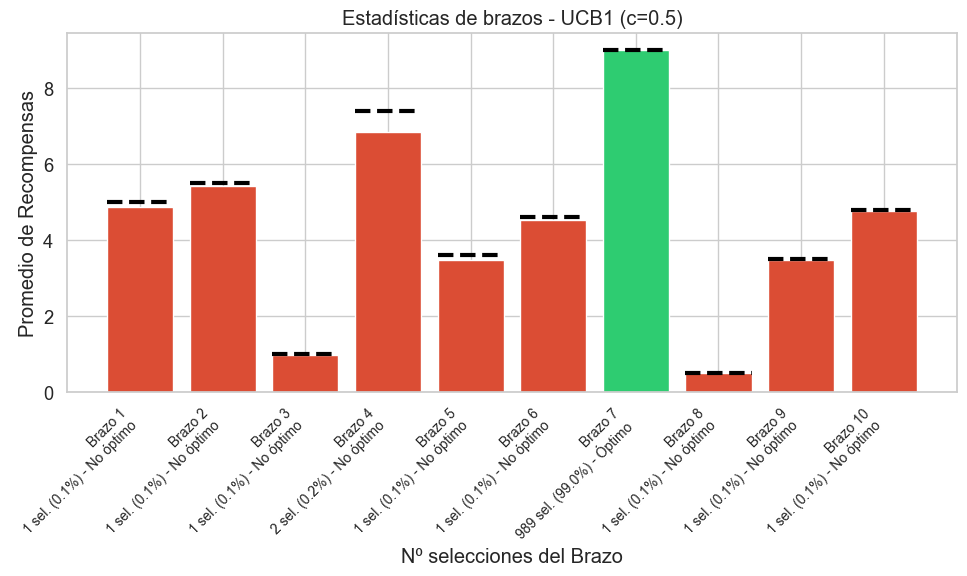

c:\Users\Usuario\Documents\GitHub\SalasOrtegaConde1\plotting\plotting.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=10)



Estadísticas de brazos - UCB1 (c=2)
Brazo 1: Recompensa Promedio = 4.6637, Selecciones = 3
Brazo 2: Recompensa Promedio = 5.2191, Selecciones = 4
Brazo 3: Recompensa Promedio = 0.8940, Selecciones = 1
Brazo 4: Recompensa Promedio = 7.2507, Selecciones = 16
Brazo 5: Recompensa Promedio = 3.2779, Selecciones = 2
Brazo 6: Recompensa Promedio = 4.3104, Selecciones = 3
Brazo 7: Recompensa Promedio = 8.9986, Selecciones = 961 (ÓPTIMO)
Brazo 8: Recompensa Promedio = 0.4210, Selecciones = 1
Brazo 9: Recompensa Promedio = 3.2431, Selecciones = 2
Brazo 10: Recompensa Promedio = 4.5113, Selecciones = 3


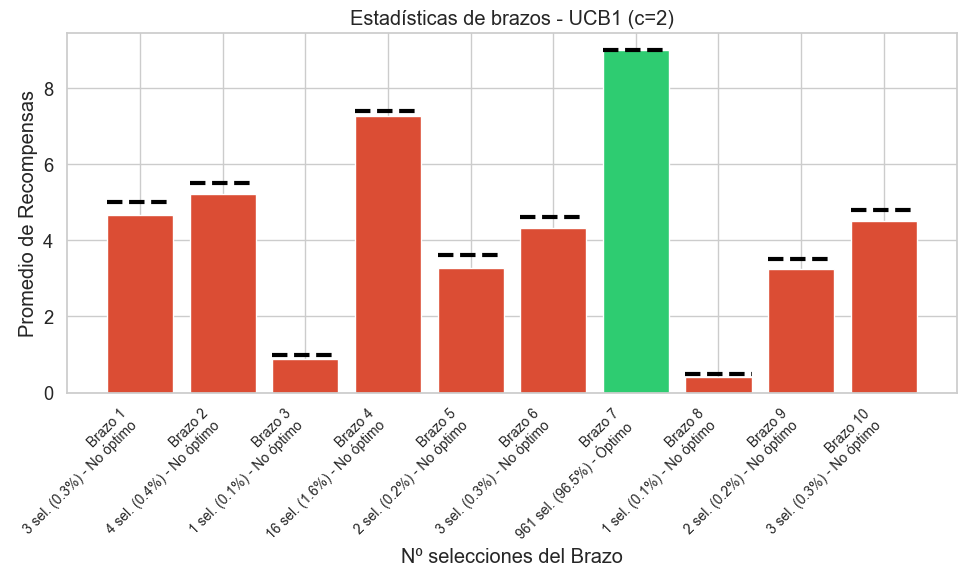

In [21]:
plot_arm_statistics(arm_stats, algorithms, [bandit.get_expected_value(i) for i in range(k)])


##### **Análisis Histogramas selección de brazos**

Estas tres gráficas muestras los diferentes histográmas de cada algoritmo, mostrándose el número de veces que ha elegido cada algoritmo a cada brazo del bandido, además de mostrar la recompensa promedia y el brazo óptimo final.

1. **Histograma de UCB1 con `C=1`:** En el primer histograma podemos ver como el brazo que más a elegido ha sido el `7` ($984$ veces), coincidiendo con el brazo óptimo del bandido. Además, podemos ver como cada brazo se ha elegido al menos una vez por la exploración inicial y como el siguiente brazo con mayor recompensa (``4``) se ha seleccionado hasta 5 veces. Esto es debido a que este algoritmo no tiene una tendencia clara a explotar o explorar, por lo que con ese segundo brazo con alto valor de recompensa se selecciona más veces.
2. **Histograma de UCB1 con `C=0.5`:** En el segundo histograma, el brazo que más veces se eligió fue el `7` ($989$ veces), volviendo a coincidir con el brazo óptimo del bandido. También vemos esa primera explorar al seleccionar todos los brazos al menos una vez, aunque en este caso, no vuelve a seleccionarlos al tender a explotar y haber un diferencia clara entre el mejor brazo y los siguientes mejores. Además, a diferencia de los resultados con la distribución de Bernoulli, al haber gran diferencia con el resto de brazos, ahora sí consigue explotar únicamente ese brazo óptimo.
3. **Histograma de UCB1 con `C=2`:** En el tercer histograma, el brazo que más veces se eligió fue el `7` ($961$ veces), volviendo a coincidir con el brazo óptimo del bandido. Esta vez vemos como el resto de brazos son seleccionados más veces que los algoritmos anteriores, aunque lo hagan en proporción a su recompensa promedio. Esta selección del resto de brazos se debe a buscar explorar más los brazos, sobre todo al inicio que ocurren estas selecciones al resto de brazos.

Como **conclusiones** de estos histogramas:

* El algoritmo **UCB1 con `C=0.5`** es el que más veces elige el brazo óptimo al explotar una vez encontrado.
* Todos los algoritmos seleccionan cada brazo al menos una vez, ayudando a saber cuales explotar.
* Se obtienen resultados similares a los obtenidos con la distribución normal debido a tener un valor de recompensa óptimo alto y separado del resto.
* El algoritmo **UCB1 con `C=2`** es el que menos veces elige el brazo óptimo al explorar el resto de brazos más veces al inicio.

Ahora, vamos a analizar los boxplots de las estimaciones de recompensas de cada brazo para cada algoritmo.

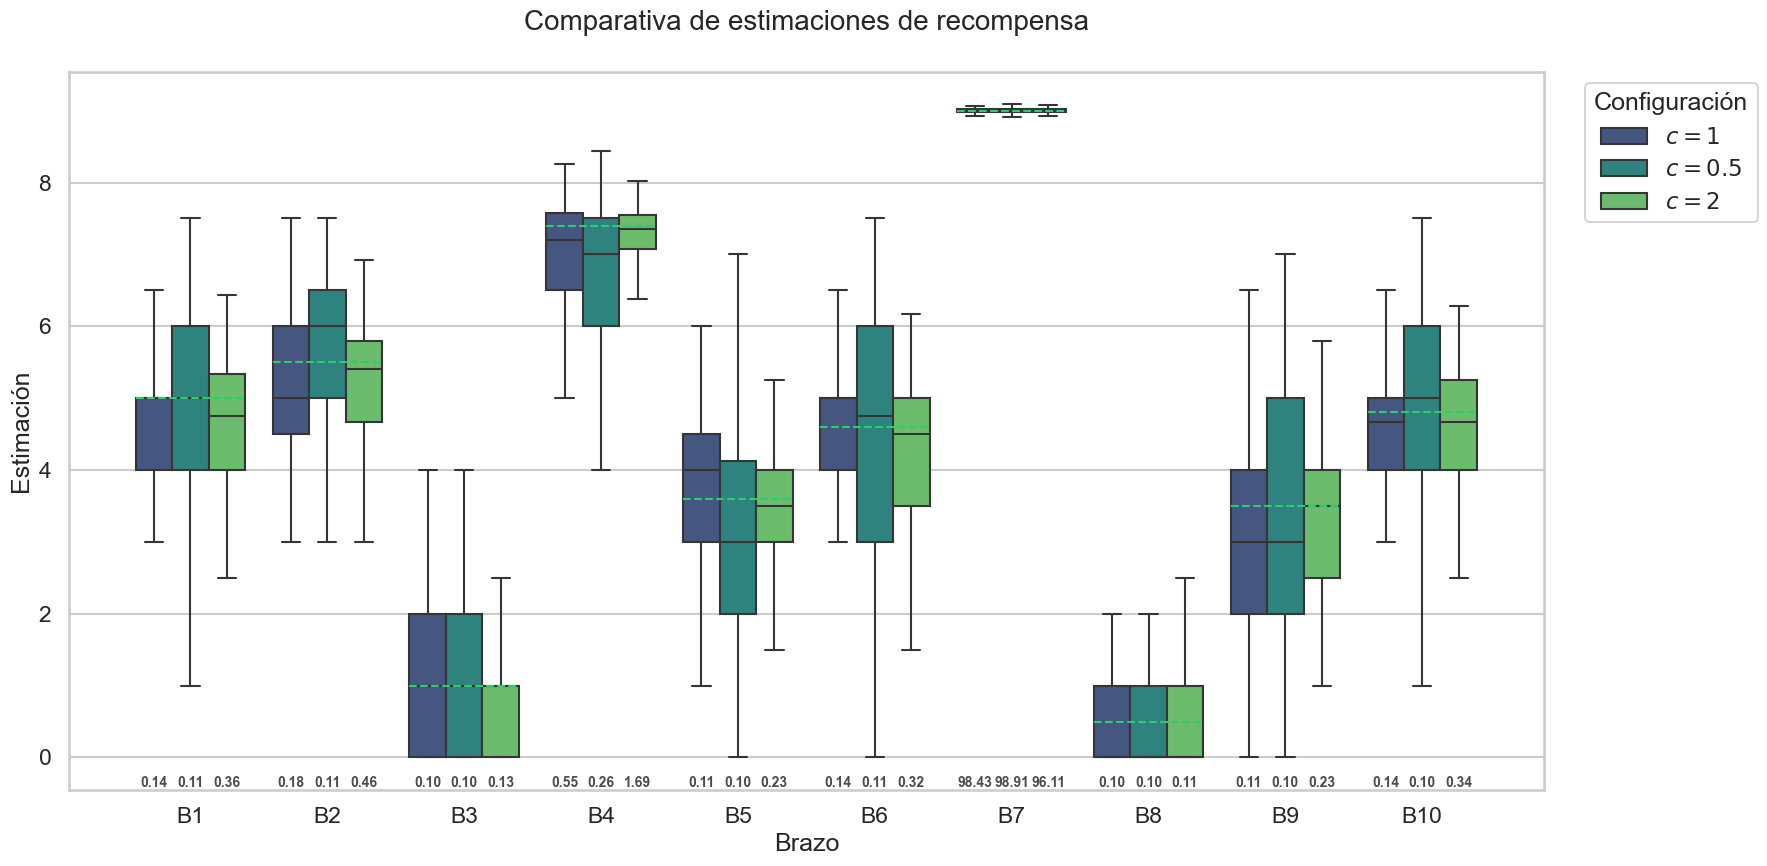

In [22]:
boxplot_estimaciones_brazos(all_runs_data, all_runs_counts, algorithms, [bandit.get_expected_value(i) for i in range(k)])

##### **Análisis Boxplots de estimaciones de recompensas de cada brazo**

Esta gráfica muestra los boxplots de las estimaciones de recompensas promedio según el número de veces que han sido seleccionado cada brazo. Para cada brazo, se muestra el boxplot para los tres algoritmos, siendo el primero el **UCB1 con `C=1`**, el segundo el **UCB1 con `C=0.5`** y el tercero **UCB1 con `C=2`**, con las estimaciones de las recompensas que el algoritmo cree que tiene cada brazo. Por otro lado, la **línea verde** indica el valor real de recompensa que tiene ese brazo. Por tanto, cuanto más apretada y cercana a la línea verde este, más precisa será la estimación.

* **Algoritmo 1 (UCB1 con `C=1`)**: Para el primer algoritmo, se puede apreciar como en todos los brazos, a excepción del 7, los boxplots se dilatan bastante, aunque el valor medio de la recompensa se situa cerca del valor real. Esto se debe a que, como vimos antes, estos brazos no son escogidos muchas veces, dando lugar a no poder visualizar el valor real. Sin embargo, con el brazo 7, siendo este el óptimo y el que más selecciona, sí encontramos un boxplot más encajado en el valor real.
* **Algoritmo 2 (UCB1 con `C=0.5`)**: Para el segundo algoritmo, nos encontramos con una situación similar a la anterior, aunque ahora hay algunos brazo, como el primero y el quinto, que las estimasciones se dilatan más. Esto se debe a que al ser el algoritmo que explota en mayor medida, no logra seleccionar esos otros brazos en más ocasiones, ocasionando que la estimación no se ajuste al valor real. Por otro lado, también vemos como se ajusta perfectamente en el brazo ``7`` al valor real.
* **Algoritmo 3 (UCB1 con `C=2`)**: Para el tercer algoritmo, ahora en todos los brazos se consigue un mejor ajuste a los valores reales, debido a que consigue explorar más esos brazos comparado con los otros algoritmos.

Como **conclusiones** de esta gráfica podemos sacar que cuando el algoritmo selecciona más veces un brazo, este cosigue poco a poco ajustarse al valor real, mientras que si solo lo selecciona una o dos veces, logra una estimación menos precisa.

Finalmente, vamos a pasar a analizar la gráfica del arrepentimiento acomulado.

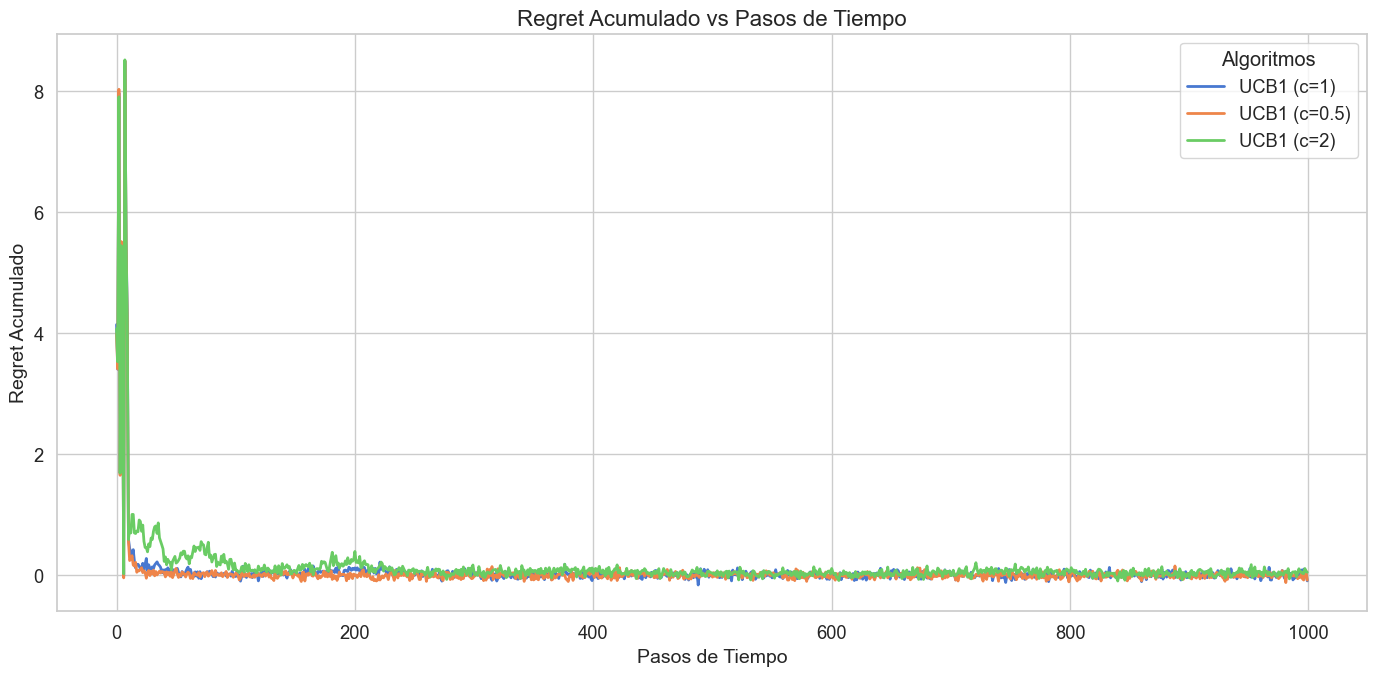

In [23]:
plot_regret(steps, regrets, algorithms)

##### **Análisis arrepentimiento acomulado**

Esta gráfica muestra la **evolución del arrepentimiento acomulado** de cada algoritmo. En el eje **x** aparece el número de pasos de tiempo que realizar cada algoritmo, de $0$ a $1000$, y en el eje **y** aparece el arrepentimiento acomulado, desde $0$ hasta $10$. La diferencia de las dos primeras gráficas es que ahora se busca disminuir el valor de arrepentimiento acomulado

* **Línea verde (UCB1 con `C=2`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explorar, dando lugar a que al inicio tarde más en llegar al valor de arrepentimiento óptimo que alcanzan el resto de algoritmos, además de ser ligeramente mayor.
* **Línea naranja (UCB1 con `C=0.5`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que tiende a explotar, dando lugar a ser el que más rápido llega al valor óptimo.
* **Línea azul (UCB1 con `C=1`)**: Muestra la evolución del arrepentimiento acomulado usando el algoritmo que no tiene una tendencia clara de explorar o explotar, obteniendo unos resultados similares al naranaj, aunque tarde ligeramente más en llegar al punto óptimo.

Como **conclusiones** de esta gráfica, vemos como tanto el algoritmo de **UCB1 con `C=0.5`** y **UCB1 con `C=1`** tardan poco en llegar al punto óptimo, mientras que el **UCB1 con `C=2`** tarda drasticamente más. Además, debido a la exploración inicial de todos los algoritmos al inicio, se ve un pico de arrepentimiento que luego se reduce hasta llegar al punto óptimo. Una vez que se han estabilizado los tres algoritmos, no se ve una clara diferencia de cual obtiene un menor valor.

## **Conclusiones**